# RNA 3D Project (same as figure)

This notebook captures the exact requirements needed to build the pipeline shown in your image:
1) Query + MSA features
2) MSA Transformer + Sequence Transformer
3) Geometry heads (distance/orientation/torsion)
4) Energy potentials
5) L-BFGS structure refinement
6) Final 3D model + evaluation


## pipeline

|------------------|----------------------|
| Query + DB MSA | `load_msa_for_chain` → `DATA_ROOT/msas/{chain_id}.a3m` (or pseudo-MSA) |
| Predicted secondary → pair init | Dot-bracket `( )` → **pair contact channel** concatenated into `pair_feat` (`collate_batch`) |
| MSA Transformer **48 blocks** | **48×** `MSAEvoformerBlock`: pair bias → row/col MSA attention → **OPM** pair update → **pair attention** |
| Pair + sequence streams | `PairEncoder`; then **4**-layer `SeqTransformer` with pair **bias** (pair summary in `d_model`) |
| **Distance / orientation maps** | From **final `pair_repr`** (2D pair trunk); **torsion** η,θ,φ from **sequence** embedding `h` |
| `pred_coords` + Kabsch MSE | Trains toward lower RMSD; **3–5 Å** needs substantial GPU training + data (not guaranteed by architecture alone) |
| **Kaggle GPU** | §1 sets `DATA_ROOT` under `/kaggle/input/...` when present; §6 training uses `batch_to_device`, mixed precision (AMP), `pin_memory` |
| NLL potentials | `geometry_nll_potential` |
| L-BFGS folding | `refine_with_lbfgs` from `pred_coords` or line init |
| Final 3D | `write_backboneish_pdb` |


In [1]:
# §1 Imports, paths, basic config
from __future__ import annotations

import math
import os
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

# Optional, for PDB export
try:
    from Bio.PDB import PDBIO, StructureBuilder
    HAVE_BIOPDB = True
except Exception:
    HAVE_BIOPDB = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch.cuda.is_available() =", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("DEVICE =", DEVICE)

# Kaggle vs local: CSVs + optional MSA folder (`msas/{chain}.a3m`)
if os.path.isdir("/kaggle"):
    DATA_ROOT = Path("/kaggle/input/datasets/riokokate/data-new")
else:
    DATA_ROOT = Path(r"C:/Users/shree/Downloads/new")

LABELS_PATH = DATA_ROOT / "train_labels_combined.csv"
SEQS_PATH = DATA_ROOT / "train_seqs_combined.csv"
SEC_PATH = DATA_ROOT / "primary_secondary (1).csv"
MSA_DIR = DATA_ROOT / "msas"

# Basic alphabet (+ explicit GAP for MSA)
TOK = {"PAD": 0, "A": 1, "U": 2, "G": 3, "C": 4, "-": 5}
IDX2TOK = {v: k for k, v in TOK.items()}

ALPHABET = {"A", "U", "G", "C"}

# Longer context for geometry (GPU memory ↑); random crop uses windows of this size when seq is longer.
MAX_LEN = 256
# Labels CSV has no resolution/R-factor; we filter by length + finite coords only.
MIN_CHAIN_LEN_GEOMETRY = 8

# Fold-level accuracy is a *research* goal (≈3–8 Å RMSD on RNAs): needs large data + long GPU training.
# This flag selects diagram-scale model + training budget when CUDA is available (set False if OOM).
TARGET_FOLD_LEVEL_ACCURACY = bool(torch.cuda.is_available())


def fold_level_training_profile(use_fold_preset: bool) -> dict[str, Any]:
    cuda = torch.cuda.is_available()
    if use_fold_preset and cuda:
        return {
            "use_full_stack": True,
            "d_msa": 128,
            "d_pair": 64,
            "d_model": 256,
            "n_heads": 8,
            "n_pair_blocks": 2,
            "max_msa": 64,
            "n_msa_blocks": None,
            "n_seq_layers": None,
            "full_epochs": 100,
            "n_train_cap": None,
            "max_steps_per_epoch": None,
            "val_fraction": 0.05,
            "lr_full": 1e-4,
            "head_lr_mult": 2.5,
            "w_coord_full": 22.0,
            "weight_decay": 5e-6,
            "batch_size_cuda": 1,
            "batch_size_cpu": 2,
        }
    return {
        "use_full_stack": False,
        "d_msa": 64,
        "d_pair": 32,
        "d_model": 128,
        "n_heads": 4,
        "n_pair_blocks": 0,
        "max_msa": 8,
        "n_msa_blocks": 4,
        "n_seq_layers": 1,
        "full_epochs": 35,
        "n_train_cap": 2048,
        "max_steps_per_epoch": None,
        "val_fraction": 0.05,
        "lr_full": 5e-5,
        "head_lr_mult": 2.0,
        "w_coord_full": 15.0,
        "weight_decay": 1e-5,
        "batch_size_cuda": 4,
        "batch_size_cpu": 2,
    }


FL = fold_level_training_profile(TARGET_FOLD_LEVEL_ACCURACY)
print(
    "TARGET_FOLD_LEVEL_ACCURACY =",
    TARGET_FOLD_LEVEL_ACCURACY,
    "| epochs=",
    FL["full_epochs"],
    "| full_stack=",
    FL["use_full_stack"],
    "| n_train_cap=",
    FL["n_train_cap"],
    "| val%=",
    FL["val_fraction"],
    "| max_steps/ep=",
    FL.get("max_steps_per_epoch"),
)
# CPU/light preset: n_train_cap=2048 and full data would be ~7k+ batches/epoch — very slow. Set n_train_cap=None for all chains.
# Optional: FL["max_steps_per_epoch"]=500 for a quick smoke test (truncates each epoch).
if not torch.cuda.is_available():
    _cap = min(MAX_LEN, 128)
    if _cap < MAX_LEN:
        print("CPU speed: MAX_LEN", MAX_LEN, "->", _cap, "(pair attn is O(L²); use GPU for 256)")
    MAX_LEN = _cap


def encode_seq(seq: str) -> torch.Tensor:
    """Map AUGC(-) string to integer tokens.

    Unknowns map to PAD.
    """
    return torch.tensor([TOK.get(c, 0) for c in str(seq).upper()], dtype=torch.long)


def one_hot(tok: torch.Tensor, vocab_size: int | None = None) -> torch.Tensor:
    if vocab_size is None:
        vocab_size = len(TOK)
    x = F.one_hot(tok.clamp(min=0, max=vocab_size - 1), num_classes=vocab_size)
    return x.float()

torch.cuda.is_available() = False
DEVICE = cpu
TARGET_FOLD_LEVEL_ACCURACY = False | epochs= 35 | full_stack= False | n_train_cap= 2048 | val%= 0.05 | max_steps/ep= None
CPU speed: MAX_LEN 256 -> 128 (pair attn is O(L²); use GPU for 256)


In [2]:
# §2 Data + feature generation: sequence, MSA, pair, secondary

import random
from pathlib import Path


def _read_fasta_like(path: Path) -> list[str]:
    """Read FASTA/A3M-like files; returns list of sequences (no headers)."""
    seqs: list[str] = []
    cur: list[str] = []
    for line in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        line = line.strip()
        if not line:
            continue
        if line.startswith(">"):
            if cur:
                seqs.append("".join(cur))
                cur = []
            continue
        cur.append(line)
    if cur:
        seqs.append("".join(cur))
    return seqs


def load_msa_for_chain(chain_id: str, query_seq: str, msa_dir: Path | None = None, max_msa: int = 32) -> list[str]:
    """Load an MSA from disk if available; else build a small pseudo-MSA.

    Expected filenames (any one is fine):
    - {chain_id}.a3m
    - {chain_id}.fasta / .fa

    CPU fallback pseudo-MSA: random point mutations + random gaps.
    """
    if msa_dir is None:
        msa_dir = globals().get("MSA_DIR", DATA_ROOT / "msas")
    cand = [msa_dir / f"{chain_id}.a3m", msa_dir / f"{chain_id}.fasta", msa_dir / f"{chain_id}.fa"]
    for p in cand:
        if p.is_file():
            seqs = _read_fasta_like(p)
            # Normalize and keep only AUGC and gaps
            norm: list[str] = []
            for s in seqs:
                s = str(s).upper()
                s = "".join([c if (c in ALPHABET or c == "-") else "-" for c in s])
                if s:
                    norm.append(s)
            if not norm:
                break
            # Ensure first sequence is the query (common A3M convention)
            if norm[0].replace("-", "") != "".join([c for c in query_seq.upper() if c in ALPHABET]):
                norm = [query_seq] + norm
            return norm[:max_msa]

    # Fallback pseudo-MSA
    q = "".join([c for c in query_seq.upper() if c in ALPHABET])
    if not q:
        q = str(query_seq).upper()

    rng = random.Random(hash(chain_id) & 0xFFFFFFFF)
    out = [q]
    for _ in range(max_msa - 1):
        s = list(q)
        # ~5% mutations
        for i in range(len(s)):
            if rng.random() < 0.05:
                s[i] = rng.choice(tuple(ALPHABET))
        # ~3% gaps
        for i in range(len(s)):
            if rng.random() < 0.03:
                s[i] = "-"
        out.append("".join(s))
    return out


@dataclass
class RNASample:
    seq: str                 # query sequence, e.g. "AUGC..."
    coords: np.ndarray       # (L, 3) ground-truth trace or backbone proxy (C4' for now)
    sec: str | None = None   # optional secondary structure string (.,() etc.)
    chain_id: str | None = None


def pdb_id_from_chain(chain_id: str | None) -> str:
    """First token before '_' truncated to 4 chars (PDB id); used for train/val split without leakage."""
    if not chain_id:
        return "unknown"
    return str(chain_id).split("_")[0].upper()[:4]


def filter_samples_for_geometry_training(
    samples: list[RNASample], min_len: int | None = None
) -> list[RNASample]:
    """Drop short chains and non-finite coords (label CSV has no resolution column to filter on)."""
    if min_len is None:
        min_len = globals().get("MIN_CHAIN_LEN_GEOMETRY", 8)
    out: list[RNASample] = []
    for s in samples:
        if len(s.seq) < min_len:
            continue
        c = np.asarray(s.coords, dtype=np.float64)
        if c.shape[0] < len(s.seq):
            continue
        if c.shape[0] > len(s.seq):
            c = c[: len(s.seq)]
        if not np.isfinite(c).all():
            continue
        out.append(RNASample(seq=s.seq, coords=c, sec=s.sec, chain_id=s.chain_id))
    return out


def split_train_val_by_pdb(
    samples: list[RNASample], val_fraction: float, seed: int
) -> tuple[list[RNASample], list[RNASample]]:
    """Hold out entire PDB ids so train/val don't share homologous structures."""
    from collections import defaultdict

    rng = random.Random(seed)
    by_pdb: dict[str, list[RNASample]] = defaultdict(list)
    for s in samples:
        by_pdb[pdb_id_from_chain(s.chain_id)].append(s)
    pdbs = list(by_pdb.keys())
    rng.shuffle(pdbs)
    n_val = max(1, int(len(pdbs) * val_fraction))
    val_ids = set(pdbs[:n_val])
    train, val = [], []
    for pid, lst in by_pdb.items():
        (val if pid in val_ids else train).extend(lst)
    return train, val


def split_train_val_random(
    samples: list[RNASample], val_fraction: float, seed: int
) -> tuple[list[RNASample], list[RNASample]]:
    rng = random.Random(seed)
    xs = list(samples)
    rng.shuffle(xs)
    n_val = max(1, int(len(xs) * val_fraction))
    return xs[n_val:], xs[:n_val]


class SimpleRNADataset(Dataset):
    """Lightweight dataset that also provides a small MSA per chain."""

    def __init__(
        self,
        samples: list[RNASample],
        msa_dir: Path | None = None,
        max_msa: int = 32,
        *,
        max_len: int | None = None,
        crop_mode: str = "prefix",
        rng_seed: int = 0,
    ):
        self.samples = samples
        self.msa_dir = msa_dir
        self.max_msa = max_msa
        self.max_len = int(max_len if max_len is not None else globals().get("MAX_LEN", 256))
        self.crop_mode = crop_mode
        self._rng = random.Random(rng_seed)

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, i: int) -> Dict[str, Any]:
        ex = self.samples[i]
        full_L = len(ex.seq)
        cap = self.max_len
        if full_L <= cap:
            start = 0
        elif self.crop_mode == "random":
            start = self._rng.randint(0, full_L - cap)
        elif self.crop_mode == "center":
            start = max(0, (full_L - cap) // 2)
        else:
            start = 0
        seq = ex.seq[start : start + cap]
        L = len(seq)
        coords_np = np.asarray(ex.coords, dtype=np.float64)[start : start + L]
        tok = encode_seq(seq)
        coords = torch.from_numpy(coords_np).float()

        chain_id = ex.chain_id if ex.chain_id is not None else f"sample_{i}"
        msa_seqs = load_msa_for_chain(chain_id, seq, msa_dir=self.msa_dir, max_msa=self.max_msa)
        # Tokenize and pad/truncate each MSA row to L
        msa_tok_rows: list[torch.Tensor] = []
        for s in msa_seqs:
            s = str(s).upper()
            # Keep length aligned: if an A3M has insertions, we just truncate to L.
            t = encode_seq(s)[:L]
            if t.numel() < L:
                t = F.pad(t, (0, L - t.numel()))
            msa_tok_rows.append(t)
        msa_tok = torch.stack(msa_tok_rows, dim=0)  # (N_msa, L)

        return {
            "chain_id": chain_id,
            "seq": seq,
            "tok": tok,
            "msa_tok": msa_tok,
            "coords": coords,
            "sec": ex.sec[start : start + L] if ex.sec is not None else None,
        }


def sec_dotbracket_to_contact(sec: str | None, L: int) -> torch.Tensor:
    """Vienna-style dot-bracket: '(' matches ')'. Returns symmetric (L,L) with 1 on paired positions."""
    m = torch.zeros(L, L, dtype=torch.float32)
    if not sec:
        return m
    stack: list[int] = []
    for pos, ch in enumerate(str(sec)[:L]):
        if ch == "(":
            stack.append(pos)
        elif ch == ")":
            if stack:
                j = stack.pop()
                m[pos, j] = 1.0
                m[j, pos] = 1.0
    return m


def collate_batch(batch: list[Dict[str, Any]]):
    """Pad to max length and max MSA depth in batch; produce
    - msa_tokens: (B, N_msa_max, L_max)
    - seq_tokens: (B, L_max)
    - pair_feat:  (B, L_max, L_max, C_pair)
    - true_coords: (B, L_max, 3)
    - mask: (B, L_max)
    """
    B = len(batch)
    Ls = [b["tok"].numel() for b in batch]
    Lm = max(Ls)
    Ns = [b["msa_tok"].shape[0] for b in batch]
    Nm = max(Ns)

    msa_tokens = []
    seq_tokens = []
    true_coords = []
    mask = []

    for b in batch:
        L = b["tok"].numel()
        padL = Lm - L

        tok = F.pad(b["tok"], (0, padL))
        coords = F.pad(b["coords"], (0, 0, 0, padL))
        m = torch.zeros(Lm)
        m[:L] = 1.0

        msa = b["msa_tok"]  # (N, L)
        # pad length
        msa = F.pad(msa, (0, padL))
        # pad depth
        if msa.shape[0] < Nm:
            msa = F.pad(msa, (0, 0, 0, Nm - msa.shape[0]))

        seq_tokens.append(tok)
        msa_tokens.append(msa)
        true_coords.append(coords)
        mask.append(m)

    msa_tokens = torch.stack(msa_tokens)        # (B, Nm, Lm)
    seq_tokens = torch.stack(seq_tokens)        # (B, Lm)
    true_coords = torch.stack(true_coords)      # (B, Lm, 3)
    mask = torch.stack(mask)                    # (B, Lm)

    # Pair features: outer product of one-hot(query) + relative position
    seq_oh = one_hot(seq_tokens)                # (B, Lm, |TOK|)
    left = seq_oh.unsqueeze(2)
    right = seq_oh.unsqueeze(1)
    pair_cat = torch.cat([left.repeat(1, 1, Lm, 1), right.repeat(1, Lm, 1, 1)], dim=-1)

    i_idx = torch.arange(Lm).view(1, Lm, 1, 1).float()
    j_idx = torch.arange(Lm).view(1, 1, Lm, 1).float()
    rel = (i_idx - j_idx) / max(Lm - 1, 1)

    sec_channels = []
    for b in batch:
        L = b["tok"].numel()
        sc = sec_dotbracket_to_contact(b.get("sec"), L)
        if sc.shape[0] < Lm:
            sc = F.pad(sc, (0, Lm - sc.shape[1], 0, Lm - sc.shape[0]))
        sec_channels.append(sc[:Lm, :Lm])
    sec_stack = torch.stack(sec_channels, dim=0).unsqueeze(-1).to(pair_cat.dtype)  # (B,Lm,Lm,1)

    pair_feat = torch.cat([pair_cat, sec_stack, rel.expand(B, Lm, Lm, 1)], dim=-1)

    return {
        "msa_tokens": msa_tokens,
        "seq_tokens": seq_tokens,
        "pair_feat": pair_feat,
        "true_coords": true_coords,
        "mask": mask,
    }


def batch_to_device(batch: Dict[str, torch.Tensor], device: torch.device) -> Dict[str, torch.Tensor]:
    """Use in training: DataLoader(pin_memory=True) + non_blocking copy to GPU."""
    return {k: v.to(device, non_blocking=(device.type == "cuda")) for k, v in batch.items()}

In [3]:
# §3 MSA transformer + sequence transformer + geometry heads


def _fix_mha_key_padding_mask(key_padding_mask: torch.Tensor | None) -> torch.Tensor | None:
    """Prevent all-masked key rows in nn.MultiheadAttention (NaN forward/backward).

    Batched padding yields (1) tail sequence columns where every MSA token is PAD, and
    (2) depth-padded MSA rows that are PAD across L — both give key_padding_mask rows
    that are entirely True. PyTorch softmax-over-empty-keys becomes NaN; unmask one key.
    """
    if key_padding_mask is None:
        return None
    kpm = key_padding_mask.bool()
    if kpm.ndim < 2:
        return kpm
    bad = kpm.all(dim=-1)
    if not bad.any():
        return kpm
    kpm = kpm.clone()
    kpm[bad, 0] = False
    return kpm


class MSABlock(nn.Module):
    def __init__(self, d_msa: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        self.row_attn = nn.MultiheadAttention(d_msa, n_heads, dropout=dropout, batch_first=True)
        self.col_attn = nn.MultiheadAttention(d_msa, n_heads, dropout=dropout, batch_first=True)
        self.ff = nn.Sequential(
            nn.LayerNorm(d_msa),
            nn.Linear(d_msa, 4 * d_msa),
            nn.GELU(),
            nn.Linear(4 * d_msa, d_msa),
        )

    def forward(
        self,
        x: torch.Tensor,
        row_key_padding_mask: torch.Tensor | None = None,
        col_key_padding_mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """MSA block with separate row/column attention.

        Shapes:
        - x: (B, N_msa, L, d)
        - row_key_padding_mask: (B*L, N_msa) for row attention (over MSA depth)
        - col_key_padding_mask: (B*N_msa, L) for column attention (over sequence length)
        """
        B, N, L, D = x.shape

        row_key_padding_mask = _fix_mha_key_padding_mask(row_key_padding_mask)
        col_key_padding_mask = _fix_mha_key_padding_mask(col_key_padding_mask)

        # Row attention: for each residue position, attend across MSA sequences.
        x_r = x.permute(0, 2, 1, 3).contiguous().view(B * L, N, D)  # (B*L, N, D)
        r_out, _ = self.row_attn(x_r, x_r, x_r, key_padding_mask=row_key_padding_mask)
        r_out = r_out.view(B, L, N, D).permute(0, 2, 1, 3).contiguous()  # (B, N, L, D)

        # Column attention: for each MSA row, attend along sequence length.
        x_c = x.contiguous().view(B * N, L, D)  # (B*N, L, D)
        c_out, _ = self.col_attn(x_c, x_c, x_c, key_padding_mask=col_key_padding_mask)
        c_out = c_out.view(B, N, L, D)

        x = x + r_out + c_out
        x = x + self.ff(x)
        return x


class OuterProductMean(nn.Module):
    """Aggregate MSA over depth into a pair matrix (OpenFold-style OPM), residual to pair_repr."""

    def __init__(self, d_msa: int, d_pair: int, c_hidden: int = 32):
        super().__init__()
        self.layer_norm = nn.LayerNorm(d_msa)
        self.linear = nn.Linear(d_msa, c_hidden * 2)
        self.linear_out = nn.Linear(c_hidden, d_pair)

    def forward(self, msa: torch.Tensor, tok_pad: torch.Tensor) -> torch.Tensor:
        # msa: (B, N, L, D); tok_pad: (B, N, L) True where query PAD token
        x = self.layer_norm(msa)
        a, b = self.linear(x).chunk(2, dim=-1)
        m = (~tok_pad).float()
        a = a * m.unsqueeze(-1)
        b = b * m.unsqueeze(-1)
        o = torch.einsum("bnik,bnjk->bijk", a, b)
        c = torch.einsum("bni,bnj->bij", m, m).clamp(min=1.0)
        o = o / c.unsqueeze(-1)
        return self.linear_out(o)


class PairAttentionBlock(nn.Module):
    """Pair self-attention (figure): for each (b, i), attend over j on pair_repr."""

    def __init__(self, d_pair: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        nh = n_heads if d_pair % n_heads == 0 else 4
        self.ln1 = nn.LayerNorm(d_pair)
        self.attn = nn.MultiheadAttention(d_pair, nh, dropout=dropout, batch_first=True)
        self.ln2 = nn.LayerNorm(d_pair)
        self.ff = nn.Sequential(
            nn.Linear(d_pair, 4 * d_pair),
            nn.GELU(),
            nn.Linear(4 * d_pair, d_pair),
        )

    def forward(self, z: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        B, L, _, D = z.shape
        m2d = (mask.unsqueeze(1) * mask.unsqueeze(2)).unsqueeze(-1)
        h = self.ln1(z).reshape(B * L, L, D)
        bl = torch.arange(B * L, device=z.device)
        b_idx = bl // L
        kpm = _fix_mha_key_padding_mask(mask[b_idx] == 0)
        ou, _ = self.attn(h, h, h, key_padding_mask=kpm)
        z = z + ou.reshape(B, L, L, D)
        z = z + self.ff(self.ln2(z))
        return z * m2d


class MSAEvoformerBlock(nn.Module):
    """One block (figure A): pair bias → MSA row/col attention → OPM updates pair → pair attention."""

    def __init__(self, d_msa: int, d_pair: int, n_heads: int, opm_hidden: int = 32):
        super().__init__()
        self.pair_bias = nn.Linear(d_pair, d_msa)
        self.msa_block = MSABlock(d_msa, n_heads)
        self.opm = OuterProductMean(d_msa, d_pair, c_hidden=opm_hidden)
        self.pair_attn = PairAttentionBlock(d_pair, n_heads=n_heads)

    def forward(
        self,
        x: torch.Tensor,
        pair_repr: torch.Tensor,
        row_kpm: torch.Tensor,
        col_kpm: torch.Tensor,
        tok_pad: torch.Tensor,
        mask: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        pb = self.pair_bias(pair_repr.mean(dim=2))
        x = x + pb.unsqueeze(1)
        x = self.msa_block(x, row_key_padding_mask=row_kpm, col_key_padding_mask=col_kpm)
        pair_repr = pair_repr + self.opm(x, tok_pad)
        pair_repr = self.pair_attn(pair_repr, mask)
        return x, pair_repr


class MSAEncoder(nn.Module):
    """Figure A: N_msa_blocks (default 48) Evoformer-style MSA stack with pair bias + OPM pair updates."""

    def __init__(self, n_blocks: int = 48, d_msa: int = 128, d_pair: int = 64, n_heads: int = 4, opm_hidden: int = 32):
        super().__init__()
        self.embed = nn.Embedding(len(TOK), d_msa, padding_idx=0)
        self.blocks = nn.ModuleList(
            [MSAEvoformerBlock(d_msa, d_pair, n_heads, opm_hidden=opm_hidden) for _ in range(n_blocks)]
        )
        self.out_ln = nn.LayerNorm(d_msa)

    def forward(
        self, msa_tokens: torch.Tensor, pair_repr: torch.Tensor, mask: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        # msa_tokens: (B, N_msa, L); pair_repr: (B, L, L, d_pair) from PairEncoder
        B, N, L = msa_tokens.shape
        x = self.embed(msa_tokens)

        tok_pad = (msa_tokens == TOK["PAD"])
        res_pad = (mask == 0).unsqueeze(1).expand(B, N, L)

        row_kpm = tok_pad.permute(0, 2, 1).contiguous().view(B * L, N)
        col_kpm = (tok_pad | res_pad).contiguous().view(B * N, L)

        for blk in self.blocks:
            x, pair_repr = blk(x, pair_repr, row_kpm, col_kpm, tok_pad, mask)

        x = self.out_ln(x)
        valid = (~tok_pad).float()
        denom = valid.sum(dim=1).clamp(min=1.0)
        out = (x * valid.unsqueeze(-1)).sum(dim=1) / denom.unsqueeze(-1)
        return out, pair_repr


class PairEncoder(nn.Module):
    def __init__(self, in_dim: int, d_pair: int = 64, n_layers: int = 2):
        super().__init__()
        layers = []
        dim = in_dim
        for _ in range(n_layers):
            layers.append(nn.LayerNorm(dim))
            layers.append(nn.Linear(dim, d_pair))
            layers.append(nn.GELU())
            dim = d_pair
        self.net = nn.Sequential(*layers)

    def forward(self, pair_feat: torch.Tensor) -> torch.Tensor:
        # pair_feat: (B, L, L, C_in)
        B, L, _, C = pair_feat.shape
        x = pair_feat.view(B * L * L, C)
        x = self.net(x)
        return x.view(B, L, L, -1)


class TrianglePairBlock(nn.Module):
    """Lightweight triangle-like pair refinement.

    This is a CPU-friendly approximation of triangular updates used in AF-style pair streams.
    """

    def __init__(self, d_pair: int, dropout: float = 0.1):
        super().__init__()
        self.left = nn.Linear(d_pair, d_pair)
        self.right = nn.Linear(d_pair, d_pair)
        self.gate = nn.Sequential(nn.Linear(d_pair, d_pair), nn.Sigmoid())
        self.out = nn.Linear(d_pair, d_pair)
        self.ln = nn.LayerNorm(d_pair)
        self.drop = nn.Dropout(dropout)

    def forward(self, z: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        # z: (B,L,L,D), mask: (B,L)
        m_pair = (mask.unsqueeze(1) * mask.unsqueeze(2)).unsqueeze(-1)  # (B,L,L,1)

        # Triangle multiplicative-like update over k dimension
        a = self.left(z)
        b = self.right(z)
        tri = torch.einsum("bikd,bkjd->bijd", a, b) / math.sqrt(max(z.shape[-1], 1))

        upd = self.out(torch.tanh(tri))
        g = self.gate(z)
        z = z + self.drop(g * upd)
        z = self.ln(z)
        z = z * m_pair
        return z


class SeqTransformer(nn.Module):
    def __init__(self, d_msa: int, d_pair: int, d_model: int = 256, n_heads: int = 8, n_layers: int = 4):
        super().__init__()
        self.seq_proj = nn.Linear(d_msa, d_model)

        # Project pair summary into the same model dimension so we can safely add it.
        self.pair_summary_proj = nn.Linear(d_pair, d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4 * d_model,
            dropout=0.1,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

    def forward(self, seq_repr: torch.Tensor, pair_repr: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        # seq_repr: (B, L, d_msa); pair_repr: (B, L, L, d_pair); mask: (B, L)
        h = self.seq_proj(seq_repr)  # (B, L, d_model)
        src_key_padding_mask = _fix_mha_key_padding_mask(mask == 0)

        # Add a summary channel from pair features.
        pair_summary = pair_repr.mean(dim=2)  # (B, L, d_pair)
        pair_summary = self.pair_summary_proj(pair_summary)  # (B, L, d_model)
        h = h + pair_summary

        h = self.encoder(h, src_key_padding_mask=src_key_padding_mask)
        return h  # (B, L, d_model)


class GeometryHeads(nn.Module):
    """Figure A outputs: distance + orientation from final pair_repr; torsions η,θ,φ from sequence trunk h."""

    def __init__(self, d_model: int, d_pair: int, n_bins: int = 32, d_pair_hidden: int = 128):
        super().__init__()
        self.dist_head = nn.Sequential(
            nn.LayerNorm(d_pair),
            nn.Linear(d_pair, d_pair_hidden),
            nn.GELU(),
            nn.Linear(d_pair_hidden, n_bins),
        )
        self.orient_head = nn.Sequential(
            nn.LayerNorm(d_pair),
            nn.Linear(d_pair, d_pair_hidden),
            nn.GELU(),
            nn.Linear(d_pair_hidden, n_bins),
        )
        self.torsion_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, 3 * n_bins),
        )
        self.n_bins = n_bins

    def forward(self, h: torch.Tensor, pair_repr: torch.Tensor) -> Dict[str, torch.Tensor]:
        B, L, _, P = pair_repr.shape
        flat = pair_repr.reshape(B * L * L, P)
        dist_logits = self.dist_head(flat).view(B, L, L, -1)
        orient_logits = self.orient_head(flat).view(B, L, L, -1)
        torsion_logits = self.torsion_head(h).view(B, L, 3, self.n_bins)
        return {"dist_logits": dist_logits, "orient_logits": orient_logits, "torsion_logits": torsion_logits}


class RNAFoldModel(nn.Module):
    """Figure A→B: Pair init → 48× (pair-biased MSA + OPM pair update) → extract sequence → 4-layer seq transformer → heads; Part B is NLL + L-BFGS in §4."""

    def __init__(self,
                 d_msa: int = 128,
                 d_pair: int = 64,
                 d_model: int = 256,
                 n_msa_blocks: int = 48,
                 n_heads: int = 8,
                 n_seq_layers: int = 4,
                 n_pair_blocks: int = 0,
                 n_bins: int = 32):
        super().__init__()
        pair_in_dim = 2 * len(TOK) + 1 + 1  # seq_i, seq_j, sec contact, rel_pos
        self.pair_enc = PairEncoder(in_dim=pair_in_dim, d_pair=d_pair)
        self.msa_enc = MSAEncoder(
            n_blocks=n_msa_blocks, d_msa=d_msa, d_pair=d_pair, n_heads=n_heads
        )
        self.pair_blocks = nn.ModuleList([TrianglePairBlock(d_pair=d_pair) for _ in range(n_pair_blocks)])

        self.seq_tr = SeqTransformer(d_msa=d_msa, d_pair=d_pair, d_model=d_model, n_heads=n_heads, n_layers=n_seq_layers)
        self.geom = GeometryHeads(d_model=d_model, d_pair=d_pair, n_bins=n_bins)
        self.coord_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, 3),
        )

    def forward(self, msa_tokens: torch.Tensor, pair_feat: torch.Tensor, mask: torch.Tensor) -> Dict[str, torch.Tensor]:
        pair_repr = self.pair_enc(pair_feat)
        seq_repr, pair_repr = self.msa_enc(msa_tokens, pair_repr, mask)
        for blk in self.pair_blocks:
            pair_repr = blk(pair_repr, mask)

        h = self.seq_tr(seq_repr, pair_repr, mask)
        out = self.geom(h, pair_repr)
        out["seq_repr"] = h
        out["pair_repr"] = pair_repr
        out["pred_coords"] = self.coord_head(h)  # (B, L, 3) — same frame as labels after training
        return out

In [4]:
# §4 Potentials from geometry heads + L-BFGS refinement (distribution NLL)


def _safe_norm(x: torch.Tensor, dim: int = -1, eps: float = 1e-8, keepdim: bool = True) -> torch.Tensor:
    return x.pow(2).sum(dim=dim, keepdim=keepdim).clamp_min(eps).sqrt()


def _angle(u: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
    """Angle between vectors u and v in [0, pi].

    Uses keepdim norms so broadcasting is stable.
    """
    un = u / _safe_norm(u, keepdim=True)
    vn = v / _safe_norm(v, keepdim=True)
    c = (un * vn).sum(dim=-1).clamp(-1.0, 1.0)
    return torch.acos(c)


def _dihedral(a: torch.Tensor, b: torch.Tensor, c: torch.Tensor, d: torch.Tensor) -> torch.Tensor:
    """Dihedral angle for points a,b,c,d in [-pi, pi]."""
    b0 = a - b
    b1 = c - b
    b2 = d - c

    b1n = b1 / _safe_norm(b1, keepdim=True)
    v = b0 - (b0 * b1n).sum(dim=-1, keepdim=True) * b1n
    w = b2 - (b2 * b1n).sum(dim=-1, keepdim=True) * b1n

    x = (v * w).sum(dim=-1)
    y = (torch.cross(b1n, v, dim=-1) * w).sum(dim=-1)
    return torch.atan2(y, x)


def _bin_index(x: torch.Tensor, lo: float, hi: float, n_bins: int) -> torch.Tensor:
    """Map x into [lo,hi] bins -> int64 in [0, n_bins-1]."""
    t = (x - lo) / max(hi - lo, 1e-8)
    idx = torch.floor(t * n_bins).to(torch.long)
    return idx.clamp(0, n_bins - 1)


def _nll_from_logits(logits: torch.Tensor, idx: torch.Tensor) -> torch.Tensor:
    """Gather NLL at idx. logits [..., K], idx [...]."""
    logp = logits.log_softmax(dim=-1)
    return -logp.gather(dim=-1, index=idx.unsqueeze(-1)).squeeze(-1)


def geometry_nll_potential(
    coords: torch.Tensor,
    dist_logits: torch.Tensor,
    orient_logits: torch.Tensor,
    torsion_logits: torch.Tensor,
    mask: torch.Tensor,
    d_min: float = 2.0,
    d_max: float = 20.0,
    w_dist: float = 1.0,
    w_orient: float = 0.5,
    w_torsion: float = 0.2,
) -> torch.Tensor:
    """Negative log-likelihood potential from predicted distributions.

    - Distance bins: [d_min, d_max]
    - Orientation bins: angle between local forward dir at i and vector i->j, in [0, pi]
    - Torsion bins: 3 dihedrals per residue in [-pi, pi]

    coords: (B,L,3)
    dist_logits/orient_logits: (B,L,L,K)
    torsion_logits: (B,L,3,K)
    mask: (B,L)
    """
    B, L, _ = coords.shape
    K = dist_logits.shape[-1]

    # Pair masks
    m_pair = mask.unsqueeze(2) * mask.unsqueeze(1)  # (B,L,L)
    eye = torch.eye(L, device=coords.device).view(1, L, L)
    m_pair = m_pair * (1.0 - eye)  # ignore i==j

    # Distances
    c_i = coords.unsqueeze(2)
    c_j = coords.unsqueeze(1)
    d_cur = _safe_norm(c_i - c_j, keepdim=False)  # (B,L,L)
    d_idx = _bin_index(d_cur, d_min, d_max, K)
    dist_nll = _nll_from_logits(dist_logits, d_idx) * m_pair

    # Orientation (simple): angle(forward_i, v_ij)
    forward = torch.zeros_like(coords)
    forward[:, :-1, :] = coords[:, 1:, :] - coords[:, :-1, :]
    v_ij = c_j - c_i  # (B,L,L,3)
    # Use explicit broadcasting (B,L,1,3) vs (B,L,L,3)
    ang = _angle(forward.unsqueeze(2), v_ij).squeeze(-1)  # (B,L,L)
    ang_idx = _bin_index(ang, 0.0, math.pi, K)
    orient_nll = _nll_from_logits(orient_logits, ang_idx) * m_pair

    # Torsions: 3 windows (aligned, no off-by-one)
    # We compute dihedrals over sliding quadruplets (i,i+1,i+2,i+3): length = L-3
    # Then assign them to three channels with different residue centers.
    taus = torch.zeros(B, L, 3, device=coords.device)
    valid_tau = torch.zeros(B, L, 3, device=coords.device)

    if L >= 4:
        a = coords[:, 0:-3, :]
        b = coords[:, 1:-2, :]
        c = coords[:, 2:-1, :]
        d = coords[:, 3:  , :]
        t = _dihedral(a, b, c, d)  # (B, L-3)

        # tau2: centered at residue i for window (i,i+1,i+2,i+3) -> residues 0..L-4
        taus[:, 0:-3, 2] = t
        valid_tau[:, 0:-3, 2] = 1.0

        # tau1: centered at residue i+1 -> residues 1..L-3
        taus[:, 1:-2, 1] = t
        valid_tau[:, 1:-2, 1] = 1.0

        # tau0: centered at residue i+2 -> residues 2..L-2
        taus[:, 2:-1, 0] = t
        valid_tau[:, 2:-1, 0] = 1.0

    # Apply residue mask
    valid_tau = valid_tau * mask.unsqueeze(-1)

    tau_idx = _bin_index(taus, -math.pi, math.pi, K)
    tors_nll = _nll_from_logits(torsion_logits, tau_idx) * valid_tau

    # Normalize
    dist_loss = dist_nll.sum() / (m_pair.sum().clamp_min(1.0))
    orient_loss = orient_nll.sum() / (m_pair.sum().clamp_min(1.0))
    tors_loss = tors_nll.sum() / (valid_tau.sum().clamp_min(1.0))

    return w_dist * dist_loss + w_orient * orient_loss + w_torsion * tors_loss


def refine_with_lbfgs(
    init_coords: torch.Tensor,
    geom: Dict[str, torch.Tensor],
    mask: torch.Tensor,
    steps: int = 120,
    lr: float = 0.2,
    grad_clip: float = 1.0,
    w_bond: float = 0.05,
    target_bond: float = 3.0,
) -> torch.Tensor:
    """Run L-BFGS refinement using NLL potentials from predicted distributions.

    Notes (CPU stability):
    - Untrained logits can yield extreme gradients; we use smaller LR and grad clipping.
    - Add a weak bond-length regularizer to prevent coordinate blow-ups.
    """
    dev = geom["dist_logits"].device
    coords = init_coords.clone().detach().to(dev)
    coords.requires_grad_(True)

    optimizer = torch.optim.LBFGS(
        [coords],
        lr=lr,
        max_iter=steps,
        history_size=30,
        line_search_fn="strong_wolfe",
        tolerance_grad=1e-7,
        tolerance_change=1e-9,
    )

    def closure():
        optimizer.zero_grad(set_to_none=True)

        loss = geometry_nll_potential(
            coords,
            dist_logits=geom["dist_logits"],
            orient_logits=geom["orient_logits"],
            torsion_logits=geom["torsion_logits"],
            mask=mask,
        )

        # Weak chain regularizer: keep adjacent distances near target_bond.
        if coords.shape[1] >= 2:
            d = _safe_norm(coords[:, 1:, :] - coords[:, :-1, :], keepdim=False)  # (B,L-1)
            m = mask[:, 1:] * mask[:, :-1]
            bond = ((d - target_bond).pow(2) * m).sum() / m.sum().clamp_min(1.0)
            loss = loss + w_bond * bond

        if not torch.isfinite(loss):
            # If loss diverged, stop gradients for this step.
            return torch.tensor(1e6, device=coords.device, requires_grad=True)

        loss.backward()
        if grad_clip is not None and grad_clip > 0:
            torch.nn.utils.clip_grad_norm_([coords], max_norm=grad_clip)
        return loss

    optimizer.step(closure)
    return coords.detach()

In [5]:
# §5 True vs predicted comparison + PDB export + evaluation plots

import matplotlib.pyplot as plt


def kabsch_align(true_xyz: torch.Tensor, pred_xyz: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """Align pred to true using Kabsch (per batch)."""
    # true_xyz/pred_xyz: (B,L,3), mask: (B,L)
    B, L, _ = true_xyz.shape
    out = pred_xyz.clone()
    for b in range(B):
        m = mask[b] > 0.5
        if m.sum() < 3:
            continue
        X = torch.nan_to_num(true_xyz[b, m, :], nan=0.0, posinf=1e4, neginf=-1e4)
        Y = torch.nan_to_num(pred_xyz[b, m, :], nan=0.0, posinf=1e4, neginf=-1e4)
        Xc = X - X.mean(dim=0, keepdim=True)
        Yc = Y - Y.mean(dim=0, keepdim=True)
        C = Yc.t() @ Xc
        try:
            V, S, Wt = torch.linalg.svd(C)
        except torch._C._LinAlgError:
            continue
        d = torch.det(V @ Wt)
        if not torch.isfinite(d):
            continue
        ds = max(-1.0, min(1.0, float(d)))
        D = torch.diag(torch.tensor([1.0, 1.0, ds], device=true_xyz.device, dtype=true_xyz.dtype))
        R = V @ D @ Wt
        t = X.mean(dim=0, keepdim=True) - (Y.mean(dim=0, keepdim=True) @ R)
        aligned = pred_xyz[b] @ R + t
        out[b] = torch.nan_to_num(aligned, nan=0.0, posinf=1e4, neginf=-1e4)
    return out


def per_residue_rmsd(true_coords: torch.Tensor, pred_coords: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """Per-residue RMSD between true and predicted (no alignment)."""
    diff2 = (true_coords - pred_coords).pow(2).sum(-1)  # (B, L)
    rms = diff2.sqrt()
    return rms * mask


def print_seq_with_errors(seq: str, errs: np.ndarray, chunk: int = 50) -> None:
    L = len(seq)
    for s in range(0, L, chunk):
        sl = seq[s : s + chunk]
        pe = errs[s : s + chunk]
        print("seq:", " ".join(sl))
        print("d:  ", " ".join(f"{x:5.2f}" for x in pe))


def write_backboneish_pdb(path: Path, coords: np.ndarray, seq: str, chain_id: str = "A", tag: str = "pred") -> None:
    """Write a pseudo full-atom-ish RNA model from a trace.

    Atoms per residue (approximate): P, C4', N9/N1.
    This is not chemically exact, but is much richer than a single-trace atom.
    """
    RES3 = {"A": "ADE", "U": "URA", "G": "GUA", "C": "CYT"}

    c = np.asarray(coords, dtype=np.float64)
    L = c.shape[0]
    if L == 0:
        path.write_text("END\n", encoding="utf-8")
        return

    # Local pseudo-frame at each residue from neighboring trace points.
    t = np.zeros_like(c)
    t[1:-1] = c[2:] - c[:-2]
    t[0] = c[1] - c[0] if L > 1 else np.array([1.0, 0.0, 0.0])
    t[-1] = c[-1] - c[-2] if L > 1 else np.array([1.0, 0.0, 0.0])

    def _norm(v):
        n = np.linalg.norm(v)
        return v / (n + 1e-8)

    serial = 1
    lines: list[str] = [f"REMARK {tag} pseudo backbone/full-atom-ish model"]

    for i in range(L):
        base = seq[i] if i < len(seq) else "A"
        rname = RES3.get(base, "ADE")

        ti = _norm(t[i])
        ref = np.array([0.0, 0.0, 1.0]) if abs(ti[2]) < 0.9 else np.array([0.0, 1.0, 0.0])
        ni = _norm(np.cross(ti, ref))
        bi = _norm(np.cross(ti, ni))

        c4 = c[i]
        # Rough offsets in local frame (angstrom)
        p = c4 - 2.0 * ti + 1.2 * ni
        n_base = c4 + 1.6 * ti + (1.0 if base in {"A", "G"} else -1.0) * 1.2 * bi

        atom_base = "N9" if base in {"A", "G"} else "N1"

        atoms = [
            ("P", p, "P"),
            ("C4'", c4, "C"),
            (atom_base, n_base, "N"),
        ]

        for aname, xyz, elem in atoms:
            x, y, z = xyz.tolist()
            lines.append(
                f"ATOM  {serial:5d} {aname:>4s} {rname:>3s} {chain_id}{i + 1:4d}    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00 20.00           {elem:>2s}"
            )
            serial += 1

    lines.append("END")
    path.write_text("\n".join(lines), encoding="utf-8")


def evaluate_one_sample(
    model: RNAFoldModel,
    sample: RNASample,
    save_pdb_pair: Tuple[str, str] | None = ("true_backboneish.pdb", "pred_backboneish.pdb"),
) -> None:
    model.eval()
    with torch.no_grad():
        ds = SimpleRNADataset([sample], crop_mode="center")
        batch = collate_batch([ds[0]])
        batch = batch_to_device(batch, DEVICE)

        msa_tokens = batch["msa_tokens"]
        pair_feat = batch["pair_feat"]
        true_coords = batch["true_coords"]
        mask = batch["mask"]

        geom = model(msa_tokens, pair_feat, mask)
        B, L, _ = true_coords.shape

        # Choose init coords (from network or straight line)
        if "pred_coords" in geom:
            init = geom["pred_coords"].detach()
        else:
            init = torch.zeros(B, L, 3, device=DEVICE)
            init[0, :, 0] = torch.linspace(0, 3.0 * (L - 1), L, device=DEVICE)

        refined = refine_with_lbfgs(init, geom, mask)

    # Move to device and clean NaNs BEFORE Kabsch
    true_dev = torch.nan_to_num(true_coords.to(DEVICE), nan=0.0, posinf=1e4, neginf=-1e4)
    mask_d = mask.to(DEVICE)
    L_valid = int(mask_d[0].sum().item())
    seq = sample.seq[:L_valid]

    # --- Direct network coordinates (Kabsch-aligned) ---
    if "pred_coords" in geom:
        pred_net = torch.nan_to_num(
            geom["pred_coords"], nan=0.0, posinf=1e4, neginf=-1e4
        )
        pred_net_aln = kabsch_align(true_dev, pred_net, mask_d)
        per_net = per_residue_rmsd(true_dev, pred_net_aln, mask_d).cpu().numpy()[0]
        rmsd_net = float(np.sqrt((per_net[:L_valid] ** 2).mean()))
        print(f"L={L_valid}  mean RMSD (direct coord head, Kabsch-aligned): {rmsd_net:.3f} Å")
    else:
        per_net = None
        rmsd_net = None

    # --- After L-BFGS ---
    pred_raw = torch.nan_to_num(refined, nan=0.0, posinf=1e4, neginf=-1e4)
    pred_aln = kabsch_align(true_dev, pred_raw, mask_d)
    per_res_raw = per_residue_rmsd(true_dev, pred_raw, mask_d).cpu().numpy()[0]
    per_res_aln = per_residue_rmsd(true_dev, pred_aln, mask_d).cpu().numpy()[0]
    overall_raw = float(np.sqrt((per_res_raw**2).mean()))
    overall_aln = float(np.sqrt((per_res_aln**2).mean()))

    print(f"L={L_valid}  mean per-residue RMSD (L-BFGS raw): {overall_raw:.3f}")
    print(f"L={L_valid}  mean per-residue RMSD (L-BFGS, Kabsch-aligned): {overall_aln:.3f}")

    print("\nPer-residue deviation (L-BFGS, Kabsch-aligned):")
    print_seq_with_errors(seq, per_res_aln)

    if save_pdb_pair is not None:
        true_np = true_coords[0].cpu().numpy()
        pred_np = refined[0].cpu().numpy()
        write_backboneish_pdb(Path(save_pdb_pair[0]), true_np, seq, "A", "true")
        write_backboneish_pdb(Path(save_pdb_pair[1]), pred_np, seq, "A", "pred")
        print("Wrote PDBs:", save_pdb_pair)

    # Plot aligned per-residue error
    plt.figure(figsize=(6, 3))
    plt.plot(per_res_aln, marker=".")
    plt.xlabel("residue index")
    plt.ylabel("RMSD (Å)")
    plt.title("Per-residue deviation — L-BFGS, Kabsch-aligned")
    plt.tight_layout()
    plt.show()

In [6]:
# §2b Build chain-level samples from your CSVs

import pandas as pd
import numpy as np
from pathlib import Path

# Paths: defined in §1 (`LABELS_PATH`, `SEQS_PATH`, `SEC_PATH`)

ALPHABET = {"A", "U", "G", "C"}


def chain_id_from_label_id(label_id: str) -> str:
    # Your labels look like: 1SCL_A_1, 1SCL_A_2, ... (chain level is 1SCL_A)
    s = str(label_id)
    return s.rsplit("_", 1)[0]


def build_samples_from_csvs(
    labels_csv: Path,
    seqs_csv: Path,
    sec_csv: Path | None = None,
    max_chains: int | None = None,
    verbose: bool = True,
) -> list[RNASample]:
    df_lab = pd.read_csv(labels_csv)
    df_lab["ID"] = df_lab["ID"].astype(str)
    df_lab["resname"] = df_lab["resname"].astype(str).str.upper()
    df_lab["chain_id"] = df_lab["ID"].map(chain_id_from_label_id)

    # Filter to A/U/G/C residues (project alphabet)
    df_lab = df_lab[df_lab["resname"].isin(ALPHABET)].copy()

    df_seq = pd.read_csv(seqs_csv)
    df_seq["target_id"] = df_seq["target_id"].astype(str)
    # Many rows are chain-level already; we just grab per-chain sequence.
    seq_map = dict(zip(df_seq["target_id"], df_seq["sequence"]))

    sec_map: dict[str, str] = {}
    if sec_csv is not None and Path(sec_csv).is_file():
        df_sec = pd.read_csv(sec_csv)
        df_sec["target_id"] = df_sec["target_id"].astype(str)
        # one row per chain_id expected
        sec_map = dict(zip(df_sec["target_id"], df_sec["secondary_structure"].astype(str)))

    # Group by chain
    chain_groups = list(df_lab.groupby("chain_id"))
    if max_chains is not None:
        chain_groups = chain_groups[:max_chains]

    samples: list[RNASample] = []
    bad_seq = 0

    for chain_id, g in chain_groups:
        g = g.sort_values("resid")

        seq_letters = "".join(g["resname"].tolist())
        L = len(seq_letters)
        if L < 5:
            continue

        coords = g[["x_1", "y_1", "z_1"]].to_numpy(dtype=np.float64)

        # Optional secondary structure
        sec = None
        if chain_id in sec_map:
            sec = sec_map[chain_id]
            if len(sec) >= L:
                sec = sec[:L]
            else:
                # If secondary structure is shorter, truncate coords.
                # (This should be rare if your data is consistent.)
                coords = coords[: len(sec)]
                seq_letters = seq_letters[: len(sec)]
                L = len(seq_letters)

        # Sanity check with train_seqs sequence string
        if chain_id in seq_map:
            seq_from_csv = str(seq_map[chain_id])
            seq_from_csv = "".join([c for c in seq_from_csv if c in ALPHABET])
            if len(seq_from_csv) >= L:
                seq_from_csv_cmp = seq_from_csv[:L]
                if seq_from_csv_cmp != seq_letters:
                    bad_seq += 1
                    if verbose and bad_seq <= 5:
                        print(f"[WARN] Sequence mismatch for {chain_id}: labels={seq_letters[:40]} csv={seq_from_csv_cmp[:40]}")
            else:
                if verbose and bad_seq <= 5:
                    print(f"[WARN] CSV sequence shorter for {chain_id}: {len(seq_from_csv)} < labels {L}")

        samples.append(RNASample(seq=seq_letters, coords=coords, sec=sec))

    if verbose:
        print(f"Built {len(samples)} samples. Sequence mismatches encountered: {bad_seq}")

    return samples


samples = build_samples_from_csvs(LABELS_PATH, SEQS_PATH, SEC_PATH)
print("Example sample:")
print("seq length:", len(samples[0].seq))
print("coords shape:", samples[0].coords.shape)
print("sec example:", (samples[0].sec[:50] if samples[0].sec is not None else None))


[WARN] Sequence mismatch for 1JGO_1: labels=UUUUUU csv=GGCAAG
[WARN] Sequence mismatch for 1JGP_1: labels=UUUUUU csv=GGCAAG
[WARN] Sequence mismatch for 1QBP_A: labels=GAGUUCGCUGGC csv=UGAGUUCGCUGG
[WARN] Sequence mismatch for 1URN_P: labels=AAUCCAUUGCACGGAUU csv=AAUCCAUUGCACUCGGA
[WARN] Sequence mismatch for 2A2E_A: labels=GGAGAGGAGCAGGCGGUCCGGGGGCGCGCGCUCCCGAAGC csv=GGAGAGGAGCAGGCGGUCCGGGGGCGCGCGCUUCCCGAGG
Built 17958 samples. Sequence mismatches encountered: 403
Example sample:
seq length: 8
coords shape: (8, 3)
sec example: ........


In [7]:
# §2c Fast/robust join: train_seqs.target_id  <->  train_labels.chain_id (from ID suffix)

import pandas as pd
import numpy as np
from pathlib import Path

ALPHABET = {"A", "U", "G", "C"}


def chain_id_from_label_id(label_id: str) -> str:
    # Example: 1SCL_A_1 -> 1SCL_A
    return str(label_id).rsplit("_", 1)[0]


def build_samples_from_csvs_fast(
    labels_csv: Path,
    seqs_csv: Path,
    sec_csv: Path | None = None,
    max_chains: int | None = None,
    chunksize: int = 250_000,
    verbose: bool = True,
    only_matched_sequences: bool = False,
) -> list[RNASample]:
    df_seq = pd.read_csv(seqs_csv, usecols=["target_id", "sequence"], dtype={"target_id": str, "sequence": str})
    target_ids = df_seq["target_id"].astype(str).tolist()
    if max_chains is not None:
        target_ids = target_ids[:max_chains]
    target_set = set(target_ids)

    seq_map = dict(zip(df_seq["target_id"].astype(str), df_seq["sequence"].astype(str)))

    sec_map: dict[str, str] = {}
    if sec_csv is not None and Path(sec_csv).is_file():
        df_sec = pd.read_csv(sec_csv, usecols=["target_id", "secondary_structure"], dtype={"target_id": str, "secondary_structure": str})
        sec_map = dict(zip(df_sec["target_id"].astype(str), df_sec["secondary_structure"].astype(str)))

    # accumulate per chain
    accum: dict[str, list[tuple[int, str, np.ndarray]]] = {}

    usecols = ["ID", "resname", "resid", "x_1", "y_1", "z_1"]
    for chunk in pd.read_csv(labels_csv, usecols=usecols, chunksize=chunksize):
        chunk["ID"] = chunk["ID"].astype(str)
        chunk["chain_id"] = chunk["ID"].map(chain_id_from_label_id)

        # filter to only chain IDs we care about
        chunk = chunk[chunk["chain_id"].isin(target_set)]
        if chunk.empty:
            continue

        chunk["resname"] = chunk["resname"].astype(str).str.upper()
        chunk = chunk[chunk["resname"].isin(ALPHABET)]
        if chunk.empty:
            continue

        # coords
        coords = chunk[["x_1", "y_1", "z_1"]].to_numpy(dtype=np.float64)
        for i, row in enumerate(chunk.itertuples(index=False)):
            # itertuples order follows usecols + chain_id
            # row: ID, resname, resid, x_1, y_1, z_1, chain_id (not guaranteed order)
            # so we access by attribute names
            chain_id = getattr(row, "chain_id")
            resid = int(getattr(row, "resid"))
            resname = str(getattr(row, "resname")).upper()
            c = coords[i]
            accum.setdefault(chain_id, []).append((resid, resname, c))

    samples: list[RNASample] = []
    missing = 0
    if verbose:
        print("Chains requested:", len(target_ids))
        print("Chains found in labels:", len(accum))

    for chain_id in target_ids:
        if chain_id not in accum:
            missing += 1
            continue
        rows = accum[chain_id]
        rows.sort(key=lambda t: t[0])
        seq_letters = "".join([r[1] for r in rows])
        coords = np.stack([r[2] for r in rows], axis=0)  # (L,3)

        sec = None
        if chain_id in sec_map:
            sec = sec_map[chain_id]
            # If secondary string length differs, we truncate to match coords.
            if sec is not None:
                sec = sec[: coords.shape[0]]

        # Optional sanity check with train_seqs sequence string
        if chain_id in seq_map:
            seq_from_csv = "".join([c for c in seq_map[chain_id] if c in ALPHABET])
            if len(seq_from_csv) >= coords.shape[0]:
                if seq_from_csv[: coords.shape[0]] != seq_letters:
                    if only_matched_sequences:
                        continue
                    if verbose:
                        print(f"[WARN] mismatch {chain_id}: labels={seq_letters[:30]} csv={seq_from_csv[:30]}")
            elif only_matched_sequences:
                continue

        samples.append(RNASample(seq=seq_letters, coords=coords, sec=sec, chain_id=chain_id))

    if verbose:
        print("Built samples:", len(samples))
        print("Missing chains (no label residues):", missing)
        if samples:
            print("First sample L:", len(samples[0].seq))
            print("First sample seq head:", samples[0].seq[:50])

    return samples


# Build chain-level samples using your exact join rule:
# target_id=1SCL_A  <->  ID=1SCL_A_1 (chain_id derived by stripping last suffix)
samples = build_samples_from_csvs_fast(
    labels_csv=LABELS_PATH,
    seqs_csv=SEQS_PATH,
    sec_csv=SEC_PATH,
    chunksize=250_000,
    verbose=True,
    only_matched_sequences=True,  # drop chains where label sequence != train_seqs CSV (cleaner labels)
)
print(f"Total chains in samples: {len(samples)}")


Chains requested: 19070
Chains found in labels: 18939
Built samples: 18504
Missing chains (no label residues): 131
First sample L: 29
First sample seq head: GGGUGCUCAGUACGAGAGGAACCGCACCC
Total chains in samples: 18504


Initialized new model on cpu


C:\Users\shree\AppData\Local\Temp\ipykernel_61096\2804723538.py:249: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)


L=29  mean RMSD (direct coord head, Kabsch-aligned): 16.778 Å
L=29  mean per-residue RMSD (L-BFGS raw): 19.331
L=29  mean per-residue RMSD (L-BFGS, Kabsch-aligned): 16.815

Per-residue deviation (L-BFGS, Kabsch-aligned):
seq: G G G U G C U C A G U A C G A G A G G A A C C G C A C C C
d:   22.76 22.66 22.42 18.09 14.96 11.76  4.86  1.16  5.70 10.57 10.55 11.50 18.53 22.06 25.36 25.01 22.48 18.68 16.74 13.30  9.34  7.94  4.37  6.86  8.11 16.22 18.43 22.83 27.32
Wrote PDBs: ('true_backboneish.pdb', 'pred_backboneish.pdb')


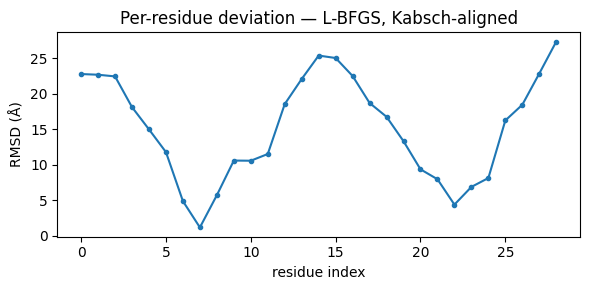

In [8]:
# Figure A→B: 48×MSA + 4×seq when FL["use_full_stack"] (set TARGET_FOLD_LEVEL_ACCURACY in §1).
USE_FULL_STACK = FL["use_full_stack"]
_n_msa = FL["n_msa_blocks"] if FL.get("n_msa_blocks") is not None else (48 if USE_FULL_STACK else 8)
_n_seq = FL["n_seq_layers"] if FL.get("n_seq_layers") is not None else (4 if USE_FULL_STACK else 2)
_need_new = (
    "model" not in globals()
    or not hasattr(model, "coord_head")
    or not hasattr(model.msa_enc.blocks[0], "pair_attn")
    or not isinstance(model.geom.dist_head[0], nn.LayerNorm)
)
if _need_new:
    model = RNAFoldModel(
        d_msa=FL["d_msa"],
        d_pair=FL["d_pair"],
        d_model=FL["d_model"],
        n_msa_blocks=_n_msa,
        n_heads=FL["n_heads"],
        n_seq_layers=_n_seq,
        n_pair_blocks=FL["n_pair_blocks"],
        n_bins=32,
    ).to(DEVICE)
    print("Initialized new model on", DEVICE)
else:
    model = model.to(DEVICE)
    print("Reusing existing model (moved to", str(DEVICE) + ").")

# Try a single chain
# Prefer a validation-chain eval after training (see training cell); center-crop in evaluate_one_sample.
test_sample = samples[0]
evaluate_one_sample(model, test_sample)

In [9]:
# §6 Training: geometry CE + coord loss. Includes **coord-head warmup** so RMSD drops before full fine-tune.
from itertools import islice

from torch.amp import GradScaler, autocast

def build_true_geometry_bins(true_coords: torch.Tensor, mask: torch.Tensor, n_bins: int = 32):
    """Build supervision bins from true coordinates with finite-value guards."""
    B, L, _ = true_coords.shape

    # Residue validity requires both sequence mask and finite xyz.
    finite_res = torch.isfinite(true_coords).all(dim=-1).float()  # (B,L)
    res_mask = mask * finite_res

    # Pair masks
    pair_mask = (res_mask.unsqueeze(1) * res_mask.unsqueeze(2))
    eye = torch.eye(L, device=true_coords.device).view(1, L, L)
    pair_mask = pair_mask * (1.0 - eye)

    # Replace non-finite coords with zeros before geometry ops
    coords = torch.nan_to_num(true_coords, nan=0.0, posinf=0.0, neginf=0.0)

    # Distance bins
    c_i = coords.unsqueeze(2)
    c_j = coords.unsqueeze(1)
    d = _safe_norm(c_i - c_j, keepdim=False)
    d = torch.nan_to_num(d, nan=2.0, posinf=20.0, neginf=2.0)
    dist_idx = _bin_index(d, 2.0, 20.0, n_bins)

    # Orientation bins
    forward = torch.zeros_like(coords)
    forward[:, :-1, :] = coords[:, 1:, :] - coords[:, :-1, :]
    v_ij = c_j - c_i
    ang = _angle(forward.unsqueeze(2), v_ij).squeeze(-1)
    ang = torch.nan_to_num(ang, nan=0.0, posinf=math.pi, neginf=0.0)
    orient_idx = _bin_index(ang, 0.0, math.pi, n_bins)

    # Torsion bins
    tors = torch.zeros(B, L, 3, device=coords.device)
    tors_mask = torch.zeros(B, L, 3, device=coords.device)

    if L >= 4:
        a = coords[:, 0:-3, :]
        b = coords[:, 1:-2, :]
        c = coords[:, 2:-1, :]
        d4 = coords[:, 3:, :]
        t = _dihedral(a, b, c, d4)  # (B, L-3)
        t = torch.nan_to_num(t, nan=0.0, posinf=math.pi, neginf=-math.pi)

        tors[:, 0:-3, 2] = t
        tors[:, 1:-2, 1] = t
        tors[:, 2:-1, 0] = t

        tors_mask[:, 0:-3, 2] = 1.0
        tors_mask[:, 1:-2, 1] = 1.0
        tors_mask[:, 2:-1, 0] = 1.0

    tors_mask = tors_mask * res_mask.unsqueeze(-1)
    tors_idx = _bin_index(tors, -math.pi, math.pi, n_bins)

    return {
        "dist_idx": dist_idx,
        "orient_idx": orient_idx,
        "tors_idx": tors_idx,
        "pair_mask": pair_mask,
        "tors_mask": tors_mask,
    }

def kabsch_mse_loss(pred: torch.Tensor, true: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    """Translation-invariant masked RMS on scaled coords (matches evaluation up to rigid translation in training)."""
    B, L, _ = pred.shape
    scale = 50.0
    P = torch.nan_to_num(pred / scale, nan=0.0, posinf=1e4, neginf=-1e4)
    T = torch.nan_to_num(true / scale, nan=0.0, posinf=1e4, neginf=-1e4)
    m = mask > 0.5
    losses: list[torch.Tensor] = []
    for b in range(B):
        mb = m[b]
        if mb.sum() < 1:
            continue
        Pb = P[b, mb] - P[b, mb].mean(0, keepdim=True)
        Tb = T[b, mb] - T[b, mb].mean(0, keepdim=True)
        losses.append((Pb - Tb).pow(2).mean().sqrt())
    if not losses:
        return pred.new_tensor(0.0)
    return torch.stack(losses).mean()


def geometry_ce_loss(geom: Dict[str, torch.Tensor], batch: Dict[str, torch.Tensor], n_bins: int = 32):
    tg = build_true_geometry_bins(batch["true_coords"], batch["mask"], n_bins=n_bins)

    # Guard logits too
    dist_logits = torch.nan_to_num(geom["dist_logits"], nan=0.0, posinf=1e3, neginf=-1e3)
    orient_logits = torch.nan_to_num(geom["orient_logits"], nan=0.0, posinf=1e3, neginf=-1e3)
    torsion_logits = torch.nan_to_num(geom["torsion_logits"], nan=0.0, posinf=1e3, neginf=-1e3)

    dist_logp = dist_logits.log_softmax(dim=-1)
    orient_logp = orient_logits.log_softmax(dim=-1)

    dist_nll = -dist_logp.gather(-1, tg["dist_idx"].unsqueeze(-1)).squeeze(-1)
    oidx = tg["orient_idx"]
    while oidx.dim() < orient_logp.dim():
        oidx = oidx.unsqueeze(-1)
    orient_nll = -orient_logp.gather(-1, oidx).squeeze(-1)

    pair_denom = tg["pair_mask"].sum().clamp_min(1.0)
    dist_loss = (dist_nll * tg["pair_mask"]).sum() / pair_denom
    orient_loss = (orient_nll * tg["pair_mask"]).sum() / pair_denom

    tors_logp = torsion_logits.log_softmax(dim=-1)  # (B,L,3,K)
    tors_nll = -tors_logp.gather(-1, tg["tors_idx"].unsqueeze(-1)).squeeze(-1)
    tors_denom = tg["tors_mask"].sum().clamp_min(1.0)
    tors_loss = (tors_nll * tg["tors_mask"]).sum() / tors_denom

    # Stronger geometry supervision (figure A: dist / orient / torsion maps)
    total = 1.2 * dist_loss + 0.6 * orient_loss + 0.4 * tors_loss
    total = torch.nan_to_num(total, nan=1e3, posinf=1e3, neginf=1e3)

    logs = {
        "loss": float(total.detach().cpu()),
        "dist": float(dist_loss.detach().cpu()),
        "orient": float(orient_loss.detach().cpu()),
        "tors": float(tors_loss.detach().cpu()),
    }
    return total, logs


def combined_training_loss(
    geom: Dict[str, torch.Tensor],
    batch: Dict[str, torch.Tensor],
    n_bins: int,
    w_coord: float = 10.0,
):
    """Geometry CE + translation-invariant coord RMS (scaled); weighted sum is the training target."""
    ce, logs = geometry_ce_loss(geom, batch, n_bins=n_bins)
    if "pred_coords" not in geom:
        return ce, logs
    coord_loss = kabsch_mse_loss(
        geom["pred_coords"].float(),
        batch["true_coords"].float(),
        batch["mask"].float(),
    )
    total = ce + w_coord * coord_loss
    logs.update(
        {
            "loss": float(total.detach().cpu()),
            "coord_mse": float(coord_loss.detach().cpu()),
        }
    )
    return total, logs


def _set_trainable_rna(model: RNAFoldModel, phase: str) -> None:
    """`heads` = geometry + coord heads only (trunk frozen); `all` = full fine-tune."""
    for name, p in model.named_parameters():
        if phase == "heads":
            p.requires_grad = name.startswith("geom") or name.startswith("coord_head")
        elif phase == "all":
            p.requires_grad = True
        else:
            raise ValueError(f"unknown phase {phase!r}")


def _train_rna_epochs(
    model: RNAFoldModel,
    dl: DataLoader,
    device: torch.device,
    epochs: int,
    lr: float,
    w_coord: float,
    weight_decay: float,
    use_amp: bool,
    desc_prefix: str,
    head_lr_mult: float | None = None,
    use_cosine_lr: bool = True,
    val_dl: DataLoader | None = None,
    max_steps_per_epoch: int | None = None,
) -> None:
    trunk_p: list[nn.Parameter] = []
    head_p: list[nn.Parameter] = []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if n.startswith("geom") or n.startswith("coord_head"):
            head_p.append(p)
        else:
            trunk_p.append(p)
    if head_lr_mult is not None and head_lr_mult > 1.0 and trunk_p and head_p:
        opt = torch.optim.AdamW(
            [
                {"params": trunk_p, "lr": lr},
                {"params": head_p, "lr": lr * head_lr_mult},
            ],
            weight_decay=weight_decay,
        )
        params = trunk_p + head_p
    else:
        params = [p for p in model.parameters() if p.requires_grad]
        if not params:
            raise RuntimeError("No trainable parameters (check _set_trainable_rna).")
        opt = torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    scaler = GradScaler("cuda", enabled=use_amp and device.type == "cuda")
    sched = (
        torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=max(epochs, 1), eta_min=max(lr * 0.02, 1e-7)
        )
        if use_cosine_lr
        else None
    )
    n_bins = model.geom.n_bins
    amp_on = use_amp and device.type == "cuda"
    n_loader = len(dl)
    n_batch_ep = (
        n_loader
        if max_steps_per_epoch is None
        else min(int(max_steps_per_epoch), n_loader)
    )
    print(
        f"[{desc_prefix}] {epochs} epochs × {n_batch_ep} batches/epoch "
        f"(loader_len={n_loader}; max_steps_per_epoch={max_steps_per_epoch}) — "
        "first batch can take minutes on CPU; long epochs are normal, not frozen."
    )
    _prev_val: tuple[float, float] | None = None
    for ep in range(1, epochs + 1):
        running = running_coord = 0.0
        running_dist = running_orient = running_tors = 0.0
        n_steps = skipped = 0
        batch_iter = dl if max_steps_per_epoch is None else islice(dl, n_batch_ep)
        pbar = tqdm(
            batch_iter,
            total=n_batch_ep,
            desc=f"{desc_prefix} {ep}/{epochs}",
            leave=False,
        )
        for batch in pbar:
            batch = batch_to_device(batch, device)
            opt.zero_grad(set_to_none=True)
            with autocast(device_type=device.type, enabled=amp_on):
                geom = model(batch["msa_tokens"], batch["pair_feat"], batch["mask"])
                loss, logs = combined_training_loss(
                    geom, batch, n_bins=n_bins, w_coord=w_coord
                )
            if not torch.isfinite(loss):
                skipped += 1
                continue
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            scaler.step(opt)
            scaler.update()
            running += logs["loss"]
            running_coord += logs.get("coord_mse", 0.0)
            running_dist += logs.get("dist", 0.0)
            running_orient += logs.get("orient", 0.0)
            running_tors += logs.get("tors", 0.0)
            n_steps += 1
            if n_steps % 10 == 0:
                pbar.set_postfix(
                    loss=f"{running/n_steps:.3f}",
                    coord=f"{running_coord/max(n_steps,1):.3f}",
                    skipped=skipped,
                )
        n_w_nan = int(sum(torch.isnan(p.detach()).sum().item() for p in model.parameters()))
        n_w_inf = int(sum(torch.isinf(p.detach()).sum().item() for p in model.parameters()))
        if n_w_nan or n_w_inf:
            print(
                f"[{desc_prefix}] WARNING ep{ep}: weight NaN elems={n_w_nan}, Inf elems={n_w_inf} — "
                "reload a fresh model; lower lr / grad clip; loss can look normal due to nan_to_num on logits."
            )
        if val_dl is not None:
            model.eval()
            v_tot = v_coord = 0.0
            v_dist = v_orient = v_tors = 0.0
            v_n = 0
            with torch.no_grad():
                for batch in val_dl:
                    batch = batch_to_device(batch, device)
                    with autocast(device_type=device.type, enabled=amp_on):
                        geom = model(batch["msa_tokens"], batch["pair_feat"], batch["mask"])
                        loss, logs = combined_training_loss(
                            geom, batch, n_bins=n_bins, w_coord=w_coord
                        )
                    if torch.isfinite(loss):
                        v_tot += float(loss.detach().cpu())
                        v_coord += logs.get("coord_mse", 0.0)
                        v_dist += logs.get("dist", 0.0)
                        v_orient += logs.get("orient", 0.0)
                        v_tors += logs.get("tors", 0.0)
                        v_n += 1
            model.train()
            if v_n > 0:
                vt, vc = v_tot / v_n, v_coord / v_n
                vd, vo, vtor = v_dist / v_n, v_orient / v_n, v_tors / v_n
                dtot = (
                    f"  Δtotal={vt - _prev_val[0]:+.3e}"
                    if _prev_val is not None
                    else ""
                )
                print(
                    f"{desc_prefix} ep{ep}/{epochs} val: total={vt:.8f} coord_rms={vc:.8f}{dtot}"
                    f"  CE dist={vd:.4f} orient={vo:.4f} tors={vtor:.4f}"
                    f"  (val_batches={v_n}, weight_NaN_elems={n_w_nan}, weight_Inf_elems={n_w_inf})"
                )
                _prev_val = (vt, vc)
        if sched is not None:
            sched.step()
        d = max(n_steps, 1)
        print(
            f"{desc_prefix} ep{ep}/{epochs}: total={running/d:.4f} coord_rms={running_coord/d:.4f} "
            f"CE dist={running_dist/d:.4f} orient={running_orient/d:.4f} tors={running_tors/d:.4f} "
            f"(steps={n_steps}, skipped={skipped}, device={device})"
        )


def train_quick_cpu(
    model: RNAFoldModel,
    samples: list[RNASample],
    device: torch.device | None = None,
    n_train: int = 200,
    epochs: int = 3,
    batch_size: int = 2,
    lr: float = 1e-4,
    max_msa: int = 8,
    w_coord: float = 15.0,
    use_amp: bool | None = None,
    num_workers: int = 0,
    weight_decay: float = 1e-5,
    head_lr_mult: float = 2.0,
    use_cosine_lr: bool = True,
):
    """Single-phase full-model training (all parameters). See `train_rna_fold` for head warmup + fine-tune."""
    if device is None:
        device = DEVICE
    if use_amp is None:
        use_amp = device.type == "cuda"
    msa_path = globals().get("MSA_DIR", DATA_ROOT / "msas")
    model.train()
    model.to(device)
    _set_trainable_rna(model, "all")
    ds = SimpleRNADataset(
        samples[:n_train],
        msa_dir=msa_path,
        max_msa=max_msa,
        crop_mode="random",
        rng_seed=42,
    )
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_batch,
        pin_memory=(device.type == "cuda"),
        num_workers=num_workers,
    )
    _train_rna_epochs(
        model,
        dl,
        device,
        epochs,
        lr,
        w_coord,
        weight_decay,
        use_amp,
        "epoch",
        head_lr_mult=head_lr_mult,
        use_cosine_lr=use_cosine_lr,
    )


def train_rna_fold(
    model: RNAFoldModel,
    samples: list[RNASample],
    device: torch.device | None = None,
    n_train: int | None = None,
    head_epochs: int = 0,
    full_epochs: int = 25,
    batch_size: int = 2,
    lr_head: float = 2e-3,
    lr_full: float = 2e-4,
    max_msa: int = 16,
    w_coord_head: float = 30.0,
    w_coord_full: float = 15.0,
    use_amp: bool | None = None,
    num_workers: int = 0,
    weight_decay: float = 1e-5,
    head_lr_mult: float = 2.0,
    use_cosine_lr: bool = True,
    min_chain_len: int | None = None,
    val_fraction: float = 0.05,
    split_by_pdb: bool = True,
    split_seed: int = 42,
    crop_rng_seed: int = 1337,
    max_steps_per_epoch: int | None = None,
) -> tuple[list[RNASample], list[RNASample]]:
    """Optional head warmup then full training on a **train** split; validates on **held-out** chains.

    **Important:** With a **randomly initialized** trunk, Phase A freezes MSA/seq/pair_enc — hidden states are
    uninformative noise, so geometry CE stays ~ln(n_bins) (~3.45 for 32 bins) and coord loss plateaus. Use
    `head_epochs=0` (default) to train **trunk + heads together** from the start. Set `head_epochs>0` only after
    the trunk already carries signal (e.g. continued training from a checkpoint)."""
    if device is None:
        device = DEVICE
    if use_amp is None:
        use_amp = device.type == "cuda"
    if min_chain_len is None:
        min_chain_len = globals().get("MIN_CHAIN_LEN_GEOMETRY", 8)
    msa_path = globals().get("MSA_DIR", DATA_ROOT / "msas")
    model.train()
    model.to(device)
    filt = filter_samples_for_geometry_training(samples, min_chain_len)
    if split_by_pdb:
        train_s, val_s = split_train_val_by_pdb(filt, val_fraction, split_seed)
    else:
        train_s, val_s = split_train_val_random(filt, val_fraction, split_seed)
    if n_train is not None:
        train_s = train_s[:n_train]
    print(
        f"Geometry: {len(train_s)} train, {len(val_s)} val | filtered {len(filt)}/{len(samples)} chains | "
        f"PDB_holdout={split_by_pdb}"
    )
    ds_train = SimpleRNADataset(
        train_s,
        msa_dir=msa_path,
        max_msa=max_msa,
        crop_mode="random",
        rng_seed=crop_rng_seed,
    )
    ds_val = SimpleRNADataset(
        val_s,
        msa_dir=msa_path,
        max_msa=max_msa,
        crop_mode="center",
        rng_seed=0,
    )
    dl = DataLoader(
        ds_train,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_batch,
        pin_memory=(device.type == "cuda"),
        num_workers=num_workers,
    )
    val_dl = (
        DataLoader(
            ds_val,
            batch_size=batch_size,
            shuffle=False,
            collate_fn=collate_batch,
            pin_memory=(device.type == "cuda"),
            num_workers=num_workers,
        )
        if len(val_s) > 0
        else None
    )
    if val_dl is not None:
        print(f"Val loader: {len(val_dl)} batches ({len(val_s)} chains)")
    if head_epochs > 0:
        print(
            "Phase A: head warmup (geom + coord_head, trunk frozen). "
            "If CE ~ln(n_bins), trunk is still random — prefer head_epochs=0 next run."
        )
        _set_trainable_rna(model, "heads")
        _train_rna_epochs(
            model,
            dl,
            device,
            head_epochs,
            lr_head,
            w_coord_head,
            weight_decay,
            use_amp,
            "head",
            head_lr_mult=None,
            use_cosine_lr=use_cosine_lr,
            val_dl=val_dl,
            max_steps_per_epoch=max_steps_per_epoch,
        )
    else:
        print("Skipping frozen-trunk warmup (head_epochs=0) — joint training.")

    print("Phase B: full model" if head_epochs > 0 else "Full model (joint)")
    _set_trainable_rna(model, "all")
    _train_rna_epochs(
        model,
        dl,
        device,
        full_epochs,
        lr_full,
        w_coord_full,
        weight_decay,
        use_amp,
        "full",
        head_lr_mult=head_lr_mult,
        use_cosine_lr=use_cosine_lr,
        val_dl=val_dl,
        max_steps_per_epoch=max_steps_per_epoch,
    )
    return train_s, val_s


In [10]:
import torch
torch.cuda.empty_cache()

Geometry: 2048 train, 859 val | filtered 16397/18504 chains | PDB_holdout=True
Val loader: 430 batches (859 chains)
Skipping frozen-trunk warmup (head_epochs=0) — joint training.
Full model (joint)
[full] 35 epochs × 1024 batches/epoch (loader_len=1024; max_steps_per_epoch=None) — first batch can take minutes on CPU; long epochs are normal, not frozen.


full 1/35:   0%|          | 0/1024 [00:00<?, ?it/s]

full ep1/35 val: total=9.35436584 coord_rms=0.30846544  CE dist=1.2415 orient=3.2932 tors=3.1540  (val_batches=430, weight_NaN_elems=0, weight_Inf_elems=0)
full ep1/35: total=8.7936 coord_rms=0.2327 CE dist=1.7269 orient=3.3054 tors=3.1185 (steps=1024, skipped=0, device=cpu)


full 2/35:   0%|          | 0/1024 [00:00<?, ?it/s]

full ep2/35 val: total=9.14621226 coord_rms=0.30843326  Δtotal=-2.082e-01  CE dist=1.1323 orient=3.1673 tors=3.1513  (val_batches=430, weight_NaN_elems=0, weight_Inf_elems=0)
full ep2/35: total=8.4832 coord_rms=0.2308 CE dist=1.5582 orient=3.1769 tors=3.1146 (steps=1024, skipped=0, device=cpu)


...

full ep33/35 val: total=8.85061836 coord_rms=0.30814355  Δtotal=+8.788e-04  CE dist=0.9794 orient=3.0166 tors=3.1081  (val_batches=430, weight_NaN_elems=0, weight_Inf_elems=0)
full ep33/35: total=7.8495 coord_rms=0.2273 CE dist=1.2513 orient=2.8786 tors=3.0270 (steps=1024, skipped=0, device=cpu)


full 34/35:   0%|          | 0/1024 [00:00<?, ?it/s]

full ep34/35 val: total=8.84893785 coord_rms=0.30812653  Δtotal=-1.681e-03  CE dist=0.9788 orient=3.0157 tors=3.1078  (val_batches=430, weight_NaN_elems=0, weight_Inf_elems=0)
full ep34/35: total=7.8676 coord_rms=0.2284 CE dist=1.2544 orient=2.8785 tors=3.0237 (steps=1024, skipped=0, device=cpu)


full 35/35:   0%|          | 0/1024 [00:00<?, ?it/s]

full ep35/35 val: total=8.84835920 coord_rms=0.30814543  Δtotal=-5.787e-04  CE dist=0.9781 orient=3.0157 tors=3.1077  (val_batches=430, weight_NaN_elems=0, weight_Inf_elems=0)
full ep35/35: total=7.8488 coord_rms=0.2274 CE dist=1.2502 orient=2.8798 tors=3.0230 (steps=1024, skipped=0, device=cpu)
L=15  mean RMSD (direct coord head, Kabsch-aligned): 8.815 Å
L=15  mean per-residue RMSD (L-BFGS raw): 17.361
L=15  mean per-residue RMSD (L-BFGS, Kabsch-aligned): 8.815

Per-residue deviation (L-BFGS, Kabsch-aligned):
seq: G C U C C A G A U G G A G C G
d:    7.89  7.12  6.40  6.20  6.30  8.89  9.64 11.88 11.84  8.01  7.04  6.73  8.00  9.15 13.18
Wrote PDBs: ('true_backboneish.pdb', 'pred_backboneish.pdb')


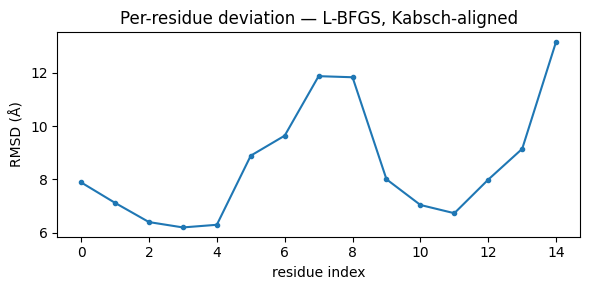

In [12]:
# CE ~ln(32)≈3.45 means heads are guessing; frozen trunk + random init cannot fix that — use head_epochs=0.
# Training budget + widths follow FL (§1); set TARGET_FOLD_LEVEL_ACCURACY=False there if GPU OOM.
# Train/val = PDB holdout + val metrics each epoch; random crop on train; center crop on val (see §1/§2).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bs = FL["batch_size_cuda"] if device.type == "cuda" else FL["batch_size_cpu"]
_cap = FL["n_train_cap"]
_n_train = None if _cap is None else min(_cap, len(samples))
train_samples, val_samples = train_rna_fold(
    model,
    samples,
    device=device,
    n_train=_n_train,
    head_epochs=0,
    full_epochs=FL["full_epochs"],
    batch_size=bs,
    lr_head=2e-3,
    lr_full=FL["lr_full"],
    max_msa=FL["max_msa"],
    w_coord_head=30.0,
    w_coord_full=FL["w_coord_full"],
    weight_decay=FL["weight_decay"],
    head_lr_mult=FL["head_lr_mult"],
    use_cosine_lr=True,
    use_amp=device.type == "cuda",
    num_workers=2 if device.type == "cuda" else 0,
    val_fraction=FL["val_fraction"],
    split_by_pdb=True,
    max_steps_per_epoch=FL.get("max_steps_per_epoch"),
)
evaluate_one_sample(model, val_samples[0] if val_samples else samples[0])